<a href="https://colab.research.google.com/github/sudeep291/InternSpark-Internship/blob/main/InternSpark_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT LIBRARIES








In [60]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#DATA COLLECTION FROM KAGGLE HUB

In [61]:
path=kagglehub.dataset_download("bhanupratapbiswas/customer-behavior-analysis")
print('original:',path)
filename = os.listdir(path)[0]
new_path=os.path.join(path,filename)
print('New_Path:',new_path)
df=pd.read_csv(new_path)
print(type(df))
df.shape

Using Colab cache for faster access to the 'customer-behavior-analysis' dataset.
original: /kaggle/input/customer-behavior-analysis
New_Path: /kaggle/input/customer-behavior-analysis/ecommerce_customer_data_large.csv
<class 'pandas.core.frame.DataFrame'>


(250000, 13)

# DATA UNDERSTANDING FROM THE DATASET


In [62]:
# first 5 records
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [63]:
# last 5 records
df.tail()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0
249999,4148,2020-09-07 05:12:19,Home,307,5,3634,Cash,32,0.0,Angela Norton,32,Male,0


In [64]:
# Column Names
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [65]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [66]:
# statistical data
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


# DATA CLEANING

In [67]:
df.nunique()

,0
Customer ID,49661
Purchase Date,249728
Product Category,4
Product Price,491
Quantity,5
Total Purchase Amount,5245
Payment Method,3
Customer Age,53
Returns,2
Customer Name,39878


In [68]:
# finding the total null values
df.isna().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [69]:
# finding the dupicates
df.duplicated().sum()

np.int64(0)

In [77]:
# ddropping the duplicates
df.drop_duplicates(inplace=True)
len(df)


250000

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [84]:
# convert the purchase date column to date (DataType)
df['Purchase Date']=pd.to_datetime(df['Purchase Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                202618 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6

In [90]:
df['Age'].head(3)

,Age
0,31
1,31
2,31


In [99]:
# drop the redundancy column
df.drop(columns=['Customer Age'],inplace=True)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 249947 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            249947 non-null  int64         
 1   Purchase Date          249947 non-null  datetime64[ns]
 2   Product Category       249947 non-null  object        
 3   Product Price          249947 non-null  int64         
 4   Quantity               249947 non-null  int64         
 5   Total Purchase Amount  249947 non-null  int64         
 6   Payment Method         249947 non-null  object        
 7   Returns                202573 non-null  float64       
 8   Customer Name          249947 non-null  object        
 9   Age                    249947 non-null  int64         
 10  Gender                 249947 non-null  object        
 11  Churn                  249947 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(6), objec

In [107]:
# printing the columns in the dataset after the dropping iof the column
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Returns',
       'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

# CALCULATING THE RFM('RECENCY-FREQUENCY-MONETERY')

In [110]:
max_date=df['Purchase Date'].max()
max_date

Timestamp('2023-09-13 18:42:49')

In [111]:
# rfm
rfm = df.groupby('Customer Name').agg({
    'Purchase Date': lambda x: (max_date - x.max()).days,
    'Customer Name': 'count',
    'Total Purchase Amount': 'sum'
}).rename(columns={
    'Purchase Date': 'Recency',
    'Customer Name': 'Frequency',
    'Total Purchase Amount': 'Monetary'
}).reset_index()


In [112]:
rfm

,Customer Name,Recency,Frequency,Monetary
0,Aaron Alexander,247,5,10727
1,Aaron Archer,331,4,11362
2,Aaron Armstrong,208,3,5150
3,Aaron Avery,133,6,20151
4,Aaron Avila,15,7,21088
...,...,...,...,...
39867,Zoe Myers,42,6,18860
39868,Zoe Torres,874,1,2809
39869,Zoe Walker,667,2,3933
39870,Zoe Watson,317,2,7019


# EDA

In [113]:
r_labels = [3, 2, 1]
f_labels = [1, 2, 3]
m_labels = [1, 2, 3]

rfm['R'] = pd.qcut(rfm['Recency'], q=3, labels=r_labels).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=f_labels).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'], q=3, labels=m_labels).astype(int)

def assign_segment(row):
    if row['R'] == 1:
        return 'At-Risk'
    elif row['F'] == 3 and row['M'] == 3:
        return 'High-Spenders'
    else:
        return 'Loyal'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
df = df.merge(rfm[['Customer Name', 'Segment']], on='Customer Name', how='left')


# VISUALIZATION

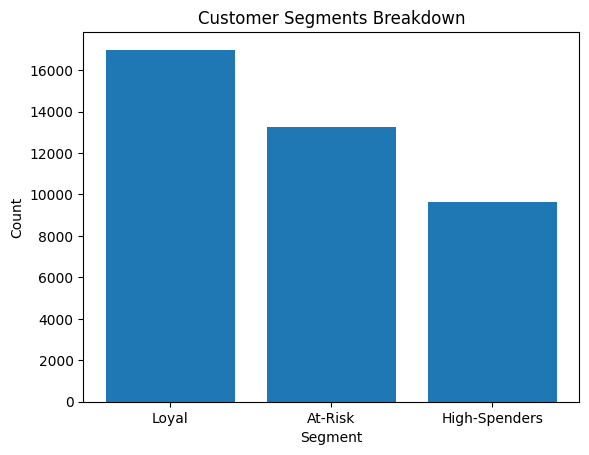

In [115]:
# Bar Chart: Customer Segments
segment_counts = rfm['Segment'].value_counts()
plt.bar(segment_counts.index, segment_counts.values)
plt.title('Customer Segments Breakdown')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

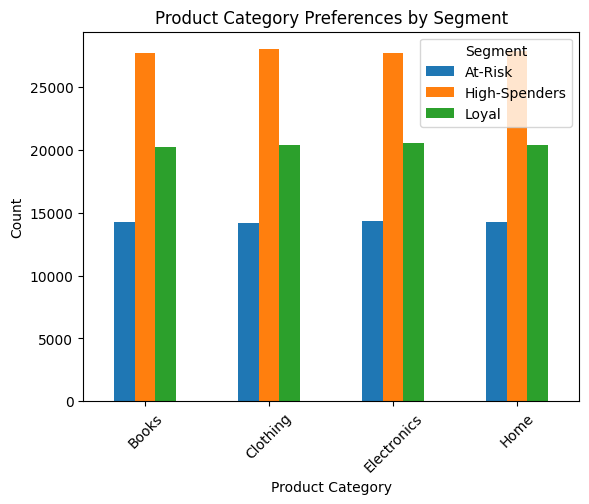

In [116]:
# Grouped Bar Chart: Product Category
category_segment = pd.crosstab(df['Product Category'], df['Segment'])
category_segment.plot(kind='bar')
plt.title('Product Category Preferences by Segment')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_809/1990072068.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=['At-Risk', 'Loyal', 'High-Spenders'])


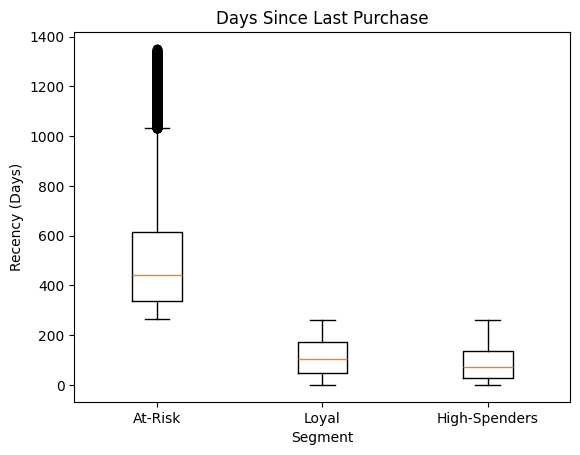

In [117]:
# Boxplot: Days Since Last Purchase
boxplot_data = [
    rfm[rfm['Segment'] == 'At-Risk']['Recency'].values,
    rfm[rfm['Segment'] == 'Loyal']['Recency'].values,
    rfm[rfm['Segment'] == 'High-Spenders']['Recency'].values
]
plt.boxplot(boxplot_data, labels=['At-Risk', 'Loyal', 'High-Spenders'])
plt.title('Days Since Last Purchase')
plt.xlabel('Segment')
plt.ylabel('Recency (Days)')
plt.show()